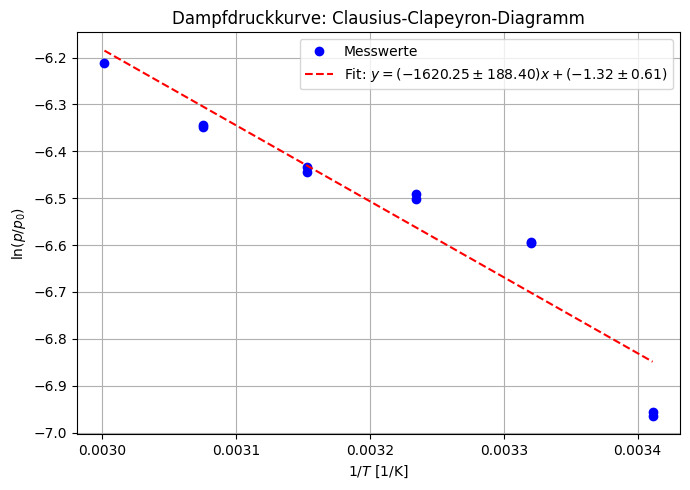

=== Lineare Regression ===
Steigung (a): -1620.2495 ± 188.3984
Achsenabschnitt (b): -1.3217 ± 0.6067
Bestimmtheitsmaß R²: 0.8915


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Daten einlesen
col_C = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl", usecols="L, M", skiprows=22, nrows=12)
col_C.columns = ["ln(p/p_0)", "T^-1 (1/K)"]

# NaNs entfernen, falls nötig
col_C = col_C.dropna()

# X- und Y-Daten extrahieren
x = col_C["T^-1 (1/K)"].values
y = col_C["ln(p/p_0)"].values

# Lineare Regression
reg = linregress(x, y)

slope = reg.slope
intercept = reg.intercept
slope_err = reg.stderr
intercept_err = reg.intercept_stderr
r_value = reg.rvalue

# Regressionslinie berechnen
x_fit = np.linspace(min(x), max(x), 100)
y_fit = slope * x_fit + intercept

# Plot mit Regressionsgerade
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, y_fit, '--', label=fr'Fit: $y = ({slope:.2f} \pm {slope_err:.2f})x + ({intercept:.2f} \pm {intercept_err:.2f})$', color='red')

plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(p/p_0)$")
plt.title("Dampfdruckkurve: Clausius-Clapeyron-Diagramm")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Fitparameter ausgeben
print("=== Lineare Regression ===")
print(f"Steigung (a): {slope:.4f} ± {slope_err:.4f}")
print(f"Achsenabschnitt (b): {intercept:.4f} ± {intercept_err:.4f}")
print(f"Bestimmtheitsmaß R²: {r_value**2:.4f}")

In [2]:
print(col_C.columns)

Index(['ln(p/p_0)', '1/T (K^-1)'], dtype='object')


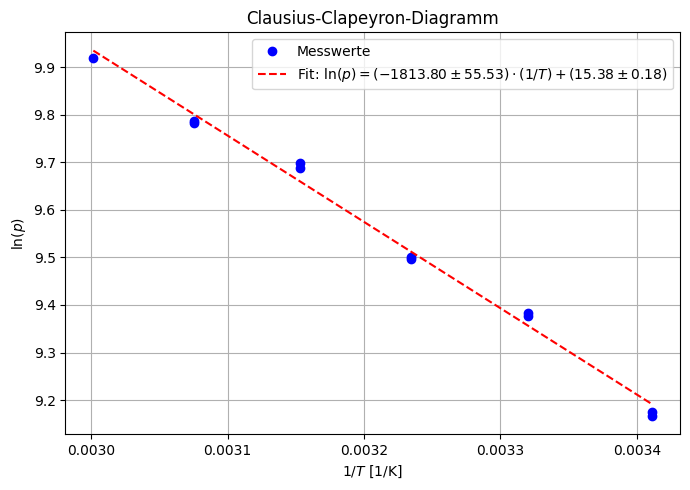

=== Fit-Ergebnisse ===
Steigung a = -1813.8006 ± 55.5276
Achsenabschnitt b = 15.3788 ± 0.1788

=== Zielgrößen ===
ΔH_verd = 1813.8006 * R = 15079.94 ± 461.66 J/mol
Siedetemperatur bei 1 bar: T = 469.18 K


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Konstanten
R = 8.314  # J/mol·K
p_norm = 1e5  # Pa (1 bar)

# Daten einlesen
col_C = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl", usecols="W, X", skiprows=22, nrows=12)
col_C.columns = ["T", "p"]
col_C = col_C.dropna()

# ln(p) und 1/T berechnen
col_C["ln(p)"] = np.log(col_C["p"])
col_C["1/T"] = 1 / col_C["T"]

# Regressionsdaten
x = col_C["1/T"].values
y = col_C["ln(p)"].values

# Lineare Regression
reg = linregress(x, y)
slope = reg.slope
intercept = reg.intercept
slope_err = reg.stderr
intercept_err = reg.intercept_stderr

# Verdampfungsenthalpie berechnen
delta_H = -slope * R  # in J/mol
delta_H_err = slope_err * R

# Siedetemperatur bei p = 1 bar: ln(p) = a·(1/T) + b → T = 1 / ((ln(p) - b)/a)
ln_p_siedepunkt = np.log(p_norm)
T_SD = -slope/intercept

# Fit-Kurve
x_fit = np.linspace(min(x), max(x), 100)
y_fit = slope * x_fit + intercept

# Plot
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, y_fit, '--', color='red',
         label=fr'Fit: $\ln(p) = ({slope:.2f} \pm {slope_err:.2f}) \cdot (1/T) + ({intercept:.2f} \pm {intercept_err:.2f})$')

plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(p)$")
plt.title("Clausius-Clapeyron-Diagramm")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Ausgabe
print("=== Fit-Ergebnisse ===")
print(f"Steigung a = {slope:.4f} ± {slope_err:.4f}")
print(f"Achsenabschnitt b = {intercept:.4f} ± {intercept_err:.4f}")

print("\n=== Zielgrößen ===")
print(f"ΔH_verd = {-slope:.4f} * R = {delta_H:.2f} ± {delta_H_err:.2f} J/mol")
print(f"Siedetemperatur bei 1 bar: T = {T_sied:.2f} K")

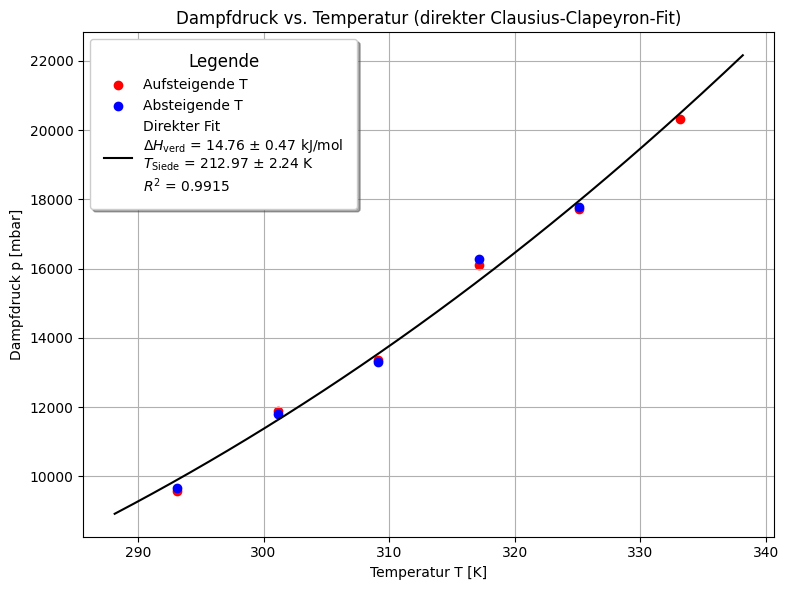


Formel: p(T) = p0 * exp[ (ΔH_v / R) * (1/T_siede - 1/T) ]
ΔH_verd = 14758.61 ± 472.31 J/mol
T_Siede = 212.97 ± 2.24 K
R² = 0.9915


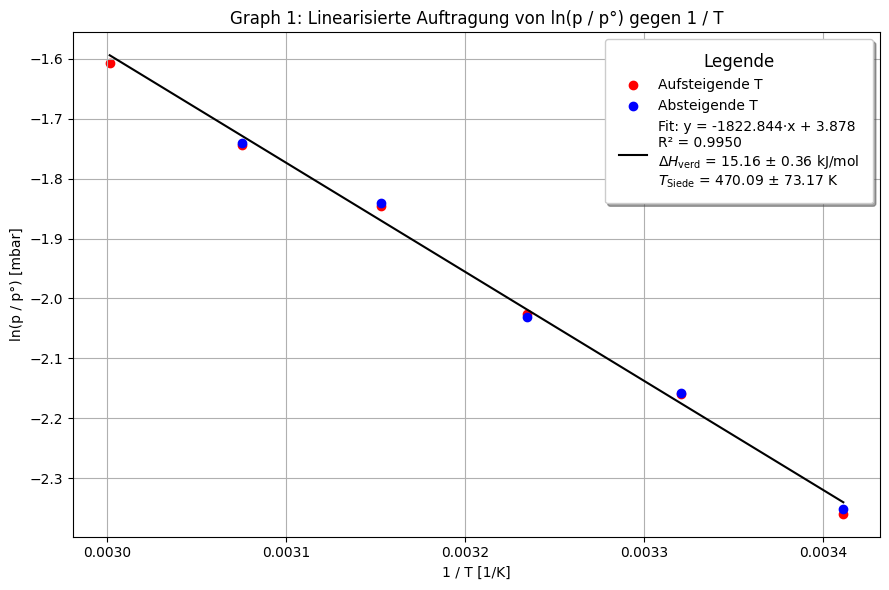

ΔH_verd = 15155.13 ± 357.39 J/mol
        = 15.16 ± 0.36 kJ/mol
T_siede = 470.09 ± 73.17 K


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Gegebene Daten
T = np.array([293.15, 301.15, 309.15, 317.15, 325.15, 333.15,
              325.15, 317.15, 309.15, 301.15, 293.15])
p_korr = np.array([95.7, 116.93, 133.7, 160.1, 177.3, 203.3, 177.9, 160.9, 133.0, 117.0, 96.5])

# Konstanten
p0 = 1013.25  # mbar
R = 8.314     # J/(mol·K)

# Linearisierte Größen
inv_T = 1 / T
ln_p = np.log(p_korr / p0)

# Trennung: aufsteigend und absteigend
inv_T_up = inv_T[:6]
ln_p_up = ln_p[:6]
inv_T_down = inv_T[6:]
ln_p_down = ln_p[6:]

# Lineare Regression
slope, intercept, r_value, p_value, std_err = linregress(inv_T, ln_p)
r_squared = r_value**2

# Zielgrößen
delta_H_v = -slope * R  # J/mol
T_siede = -slope / intercept  # K
delta_H_v_err = R * std_err

# Fehler Achsenabschnitt (intercept)
n = len(inv_T)
residuals = ln_p - (slope * inv_T + intercept)
s_yx = np.sqrt(np.sum(residuals**2) / (n - 2))
s_xx = np.sum((inv_T - np.mean(inv_T))**2)
intercept_err = s_yx * np.sqrt(1/n + (np.mean(inv_T)**2) / s_xx)

# Fehler T_siede
T_siede_err = T_siede * np.sqrt((std_err / slope)*2 + (intercept_err / intercept)*2)

# Fitlinie
x_fit = np.linspace(inv_T.min(), inv_T.max(), 300)
y_fit = slope * x_fit + intercept

# Fit-Info als String für Legende
fit_info = (
    f"Fit: y = {slope:.3f}·x + {intercept:.3f}\n"
    f"R² = {r_squared:.4f}\n"
    f"$\\Delta H_{{\\mathrm{{verd}}}}$ = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol\n" \
    f"$T_{{\\mathrm{{Siede}}}}$ = {T_siede:.2f} ± {T_siede_err:.2f} K"

)

# Plot
plt.figure(figsize=(9, 6))
plt.scatter(inv_T_up, ln_p_up, color='red', label='Aufsteigende T')
plt.scatter(inv_T_down, ln_p_down, color='blue', label='Absteigende T')
plt.plot(x_fit, y_fit, color='black', label=fit_info)

plt.xlabel('1 / T [1/K]')
plt.ylabel('ln(p / p°) [mbar]')
plt.title('Graph 1: Linearisierte Auftragung von ln(p / p°) gegen 1 / T')
plt.grid(True)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, borderpad=1, ncol=1,
   title='Legende', title_fontsize=12)
plt.tight_layout()
plt.show()

# Ergebnisse ausgeben
print(f"ΔH_verd = {delta_H_v:.2f} ± {delta_H_v_err:.2f} J/mol")
print(f"        = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol")
print(f"T_siede = {T_siede:.2f} ± {T_siede_err:.2f} K")

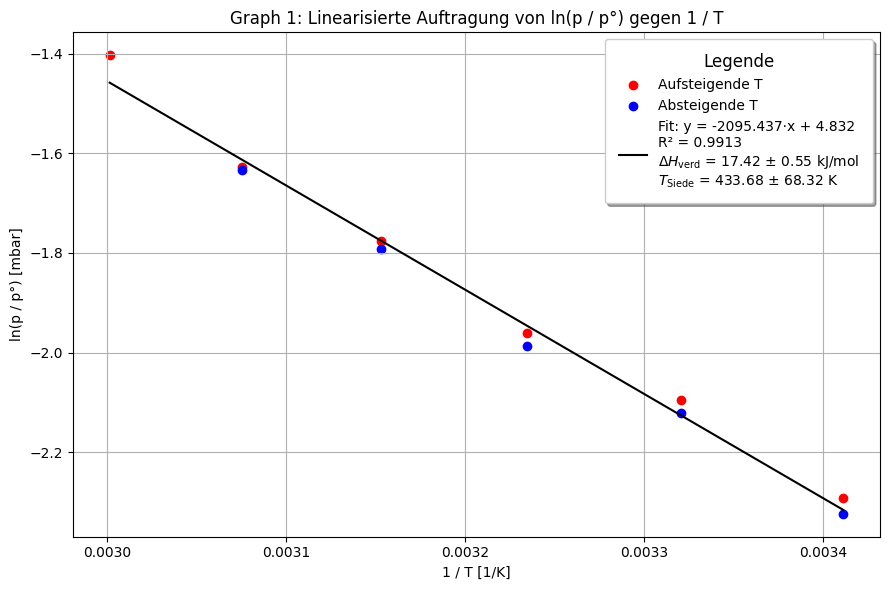

ΔH_verd = 17421.46 ± 545.18 J/mol
        = 17.42 ± 0.55 kJ/mol
T_siede = 433.68 ± 68.32 K


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Gegebene Daten
T = np.array([293.15, 301.15, 309.15, 317.15, 325.15, 333.15,
              325.15, 317.15, 309.15, 301.15, 293.15])
p_korr = np.array([95.42, 116.32, 132.91, 159.91, 185.82, 232.36, 184.54, 157.49, 129.57, 113.35, 92.5])

# Konstanten
p0 = 945  # mbar
R = 8.314     # J/(mol·K)

# Linearisierte Größen
inv_T = 1 / T
ln_p = np.log(p_korr / p0)

# Trennung: aufsteigend und absteigend
inv_T_up = inv_T[:6]
ln_p_up = ln_p[:6]
inv_T_down = inv_T[6:]
ln_p_down = ln_p[6:]

# Lineare Regression
slope, intercept, r_value, p_value, std_err = linregress(inv_T, ln_p)
r_squared = r_value**2

# Zielgrößen
delta_H_v = -slope * R  # J/mol
T_siede = -slope / intercept  # K
delta_H_v_err = R * std_err

# Fehler Achsenabschnitt (intercept)
n = len(inv_T)
residuals = ln_p - (slope * inv_T + intercept)
s_yx = np.sqrt(np.sum(residuals**2) / (n - 2))
s_xx = np.sum((inv_T - np.mean(inv_T))**2)
intercept_err = s_yx * np.sqrt(1/n + (np.mean(inv_T)**2) / s_xx)

# Fehler T_siede
T_siede_err = T_siede * np.sqrt((std_err / slope)*2 + (intercept_err / intercept)*2)

# Fitlinie
x_fit = np.linspace(inv_T.min(), inv_T.max(), 300)
y_fit = slope * x_fit + intercept

# Fit-Info als String für Legende
fit_info = (
    f"Fit: y = {slope:.3f}·x + {intercept:.3f}\n"
    f"R² = {r_squared:.4f}\n"
    f"$\\Delta H_{{\\mathrm{{verd}}}}$ = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol\n" \
    f"$T_{{\\mathrm{{Siede}}}}$ = {T_siede:.2f} ± {T_siede_err:.2f} K"

)

# Plot
plt.figure(figsize=(9, 6))
plt.scatter(inv_T_up, ln_p_up, color='red', label='Aufsteigende T')
plt.scatter(inv_T_down, ln_p_down, color='blue', label='Absteigende T')
plt.plot(x_fit, y_fit, color='black', label=fit_info)

plt.xlabel('1 / T [1/K]')
plt.ylabel('ln(p / p°) [mbar]')
plt.title('Graph 1: Linearisierte Auftragung von ln(p / p°) gegen 1 / T')
plt.grid(True)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, borderpad=1, ncol=1,
   title='Legende', title_fontsize=12)
plt.tight_layout()
plt.show()

# Ergebnisse ausgeben
print(f"ΔH_verd = {delta_H_v:.2f} ± {delta_H_v_err:.2f} J/mol")
print(f"        = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol")
print(f"T_siede = {T_siede:.2f} ± {T_siede_err:.2f} K")

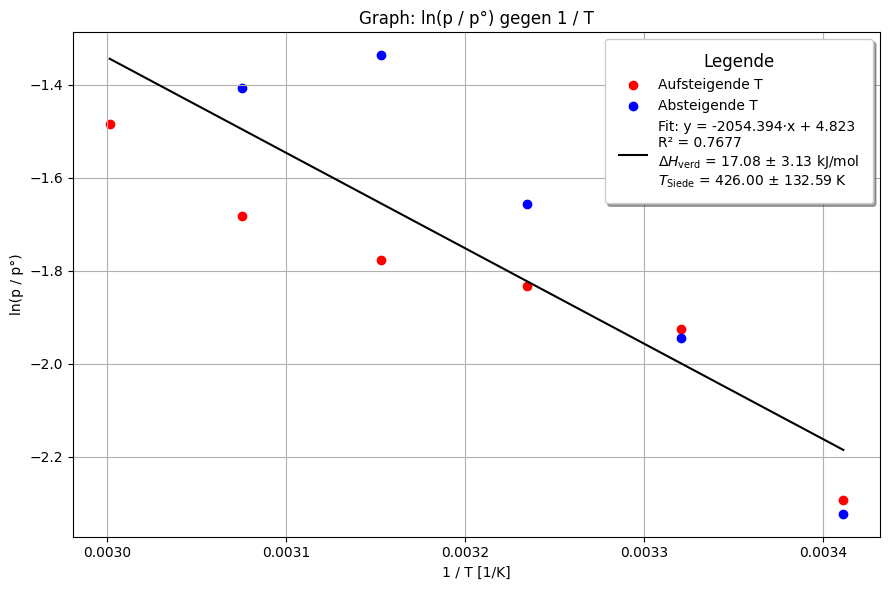

ΔH_verd = 17080.23 ± 3131.47 J/mol
        = 17.08 ± 3.13 kJ/mol
T_siede = 426.00 ± 132.59 K


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Gegebene Daten
T = np.array([293.15, 301.15, 309.15, 317.15, 325.15, 333.15,
              325.15, 317.15, 309.15, 301.15, 293.15])
p_korr = np.array([95.42, 137.92, 151.11, 159.91, 175.82, 214.06, 231.54, 248.29, 180.27, 135.15, 92.6])

# Konstanten
p0 = 945  # mbar
R = 8.314     # J/(mol·K)

# Linearisierte Größen
inv_T = 1 / T
ln_p = np.log(p_korr / p0)

# Trennung: aufsteigend und absteigend
inv_T_up = inv_T[:6]
ln_p_up = ln_p[:6]
inv_T_down = inv_T[6:]
ln_p_down = ln_p[6:]

# Lineare Regression
slope, intercept, r_value, p_value, std_err = linregress(inv_T, ln_p)
r_squared = r_value**2

# Zielgrößen
delta_H_v = -slope * R  # J/mol
T_siede = -slope / intercept  # K
delta_H_v_err = R * std_err

# Fehler Achsenabschnitt (intercept)
n = len(inv_T)
residuals = ln_p - (slope * inv_T + intercept)
s_yx = np.sqrt(np.sum(residuals**2) / (n - 2))
s_xx = np.sum((inv_T - np.mean(inv_T))**2)
intercept_err = s_yx * np.sqrt(1/n + (np.mean(inv_T)**2) / s_xx)

# KORRIGIERTE Gaußsche Fehlerfortpflanzung:
T_siede_err = T_siede * np.sqrt((std_err / slope)**2 + (intercept_err / intercept)**2)

# Fitlinie
x_fit = np.linspace(inv_T.min(), inv_T.max(), 300)
y_fit = slope * x_fit + intercept

# Fit-Info als String für Legende
fit_info = (
    f"Fit: y = {slope:.3f}·x + {intercept:.3f}\n"
    f"R² = {r_squared:.4f}\n"
    f"$\\Delta H_{{\\mathrm{{verd}}}}$ = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol\n"
    f"$T_{{\\mathrm{{Siede}}}}$ = {T_siede:.2f} ± {T_siede_err:.2f} K"
)

# Plot
plt.figure(figsize=(9, 6))
plt.scatter(inv_T_up, ln_p_up, color='red', label='Aufsteigende T')
plt.scatter(inv_T_down, ln_p_down, color='blue', label='Absteigende T')
plt.plot(x_fit, y_fit, color='black', label=fit_info)

plt.xlabel('1 / T [1/K]')
plt.ylabel('ln(p / p°)')
plt.title('Graph: ln(p / p°) gegen 1 / T')
plt.grid(True)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, borderpad=1, ncol=1,
           title='Legende', title_fontsize=12)
plt.tight_layout()
plt.show()

# Ergebnisse ausgeben
print(f"ΔH_verd = {delta_H_v:.2f} ± {delta_H_v_err:.2f} J/mol")
print(f"        = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol")
print(f"T_siede = {T_siede:.2f} ± {T_siede_err:.2f} K")